In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns

sns.set_theme(style="darkgrid")

In [142]:
data = pd.read_csv("./datasets/data.csv")

In [47]:
data.shape

(1394, 12)

In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1394 entries, 0 to 1393
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          1394 non-null   object
 1   carbune       1394 non-null   int64 
 2   consum        1394 non-null   int64 
 3   hidro         1394 non-null   int64 
 4   hidrocarburi  1394 non-null   int64 
 5   nuclear       1394 non-null   int64 
 6   eolian        1394 non-null   int64 
 7   productie     1394 non-null   int64 
 8   fotovolt      1394 non-null   int64 
 9   biomasa       1394 non-null   int64 
 10  stocare       1394 non-null   int64 
 11  sold          1394 non-null   int64 
dtypes: int64(11), object(1)
memory usage: 130.8+ KB


In [49]:
data.head(10)

,date,carbune,consum,hidro,hidrocarburi,nuclear,eolian,productie,fotovolt,biomasa,stocare,sold
0,2025-08-31 16:55:27,582,5030,729,483,1348,526,4191,369,46,107,838
1,2025-08-31 07:25:32,612,4714,943,478,1348,242,3816,48,45,96,898
2,2025-08-30 21:56:13,606,6359,1873,512,1344,650,5102,-2,47,71,1257
3,2025-08-30 12:25:36,606,4494,639,477,1345,41,4580,1422,47,0,-85
4,2025-08-30 02:25:29,607,5123,874,1307,1346,110,4289,-3,45,0,833
5,2025-08-29 16:56:31,778,5433,737,1088,1335,531,5776,1226,49,28,-343
6,2025-08-29 07:25:19,760,5888,1427,1338,1350,379,5520,112,48,103,367
7,2025-08-28 21:55:11,811,6869,1971,1279,1337,598,6060,-3,57,8,808
8,2025-08-28 12:25:31,792,4743,508,1100,1290,261,5797,1785,58,0,-1053
9,2025-08-28 02:55:22,803,5052,873,1314,1341,141,4523,-4,54,0,529


In [50]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
carbune,1394.0,801.818508,166.637846,231.0,712.00,799.0,889.75,1428.0
consum,1394.0,6074.545911,995.718552,2589.0,5329.00,5940.5,6769.00,8605.0
hidro,1394.0,1522.087518,518.169665,284.0,1134.00,1432.5,1856.75,3293.0
hidrocarburi,1394.0,1118.029412,458.328586,156.0,777.25,1168.0,1503.00,1923.0
nuclear,1394.0,1224.837877,269.530729,591.0,1303.25,1351.0,1378.00,1426.0
eolian,1394.0,694.596126,619.596039,-19.0,202.50,497.0,1049.50,2703.0
productie,1394.0,5710.825681,998.722244,2879.0,5047.00,5586.5,6346.00,9070.0
fotovolt,1394.0,290.763271,417.885868,-7.0,-2.00,9.5,534.25,1796.0
biomasa,1394.0,49.692970,10.262967,7.0,43.00,51.0,56.00,75.0
stocare,1394.0,5.038737,18.819006,0.0,0.00,0.0,0.00,194.0


In [51]:
# Verificam date lipsa
data.isnull().sum()

date            0
carbune         0
consum          0
hidro           0
hidrocarburi    0
nuclear         0
eolian          0
productie       0
fotovolt        0
biomasa         0
stocare         0
sold            0
dtype: int64

In [52]:
# Verificam daca avem randuri dublicate
data[data.duplicated()]

,date,carbune,consum,hidro,hidrocarburi,nuclear,eolian,productie,fotovolt,biomasa,stocare,sold


In [145]:
# Transformarea datei
data.date = pd.to_datetime(data.date, errors="coerce")
print(data.head(5)["date"])
print()
data.info()

0   2025-08-31 16:55:27
1   2025-08-31 07:25:32
2   2025-08-30 21:56:13
3   2025-08-30 12:25:36
4   2025-08-30 02:25:29
Name: date, dtype: datetime64[ns]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1394 entries, 0 to 1393
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1394 non-null   datetime64[ns]
 1   carbune       1394 non-null   int64         
 2   consum        1394 non-null   int64         
 3   hidro         1394 non-null   int64         
 4   hidrocarburi  1394 non-null   int64         
 5   nuclear       1394 non-null   int64         
 6   eolian        1394 non-null   int64         
 7   productie     1394 non-null   int64         
 8   fotovolt      1394 non-null   int64         
 9   biomasa       1394 non-null   int64         
 10  stocare       1394 non-null   int64         
 11  sold          1394 non-null   int64         
dtypes: datetime64[ns](1), int64(11)
m

In [146]:
data["an"] = data.date.dt.year
data["luna"] = data.date.dt.month
data["zi"] = data.date.dt.day
data["ora"] = data.date.dt.hour
data["minute"] = data.date.dt.minute
data["ziSapt"] = data.date.dt.weekday
data.head(5)

,date,carbune,consum,hidro,hidrocarburi,nuclear,eolian,productie,fotovolt,biomasa,stocare,sold,an,luna,zi,ora,minute,ziSapt
0,2025-08-31 16:55:27,582,5030,729,483,1348,526,4191,369,46,107,838,2025,8,31,16,55,6
1,2025-08-31 07:25:32,612,4714,943,478,1348,242,3816,48,45,96,898,2025,8,31,7,25,6
2,2025-08-30 21:56:13,606,6359,1873,512,1344,650,5102,-2,47,71,1257,2025,8,30,21,56,5
3,2025-08-30 12:25:36,606,4494,639,477,1345,41,4580,1422,47,0,-85,2025,8,30,12,25,5
4,2025-08-30 02:25:29,607,5123,874,1307,1346,110,4289,-3,45,0,833,2025,8,30,2,25,5


In [55]:
data[["an", "luna", "zi", "ora", "minute", "ziSapt"]].describe().T

,count,mean,std,min,25%,50%,75%,max
an,1394.0,2024.381636,0.485962,2024.0,2024.0,2024.0,2025.0,2025.0
luna,1394.0,5.753228,3.162858,1.0,3.0,6.0,8.0,12.0
zi,1394.0,15.769727,8.810483,1.0,8.0,16.0,23.0,31.0
ora,1394.0,11.066714,6.900420,0.0,5.0,11.0,17.0,23.0
minute,1394.0,31.444763,18.002238,0.0,17.0,29.0,47.0,59.0
ziSapt,1394.0,3.019369,2.006536,0.0,1.0,3.0,5.0,6.0


In [56]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1394 entries, 0 to 1393
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          1394 non-null   datetime64[ns]
 1   carbune       1394 non-null   int64         
 2   consum        1394 non-null   int64         
 3   hidro         1394 non-null   int64         
 4   hidrocarburi  1394 non-null   int64         
 5   nuclear       1394 non-null   int64         
 6   eolian        1394 non-null   int64         
 7   productie     1394 non-null   int64         
 8   fotovolt      1394 non-null   int64         
 9   biomasa       1394 non-null   int64         
 10  stocare       1394 non-null   int64         
 11  sold          1394 non-null   int64         
 12  an            1394 non-null   int32         
 13  luna          1394 non-null   int32         
 14  zi            1394 non-null   int32         
 15  ora           1394 non-null   int32   

In [57]:
data.columns

Index(['date', 'carbune', 'consum', 'hidro', 'hidrocarburi', 'nuclear',
       'eolian', 'productie', 'fotovolt', 'biomasa', 'stocare', 'sold', 'an',
       'luna', 'zi', 'ora', 'minute', 'ziSapt'],
      dtype='object')

In [58]:
TIPURI_ENERGIE = { 'carbune', 'hidro', 'hidrocarburi', 'nuclear', 'eolian', 'fotovolt', 'biomasa' }
tipuri_energie_cols = [c for c in TIPURI_ENERGIE if c in data.columns]

In [59]:
statistici = data[tipuri_energie_cols].describe().T
statistici.sort_values("max", ascending=False)

,count,mean,std,min,25%,50%,75%,max
hidro,1394.0,1522.087518,518.169665,284.0,1134.00,1432.5,1856.75,3293.0
eolian,1394.0,694.596126,619.596039,-19.0,202.50,497.0,1049.50,2703.0
hidrocarburi,1394.0,1118.029412,458.328586,156.0,777.25,1168.0,1503.00,1923.0
fotovolt,1394.0,290.763271,417.885868,-7.0,-2.00,9.5,534.25,1796.0
carbune,1394.0,801.818508,166.637846,231.0,712.00,799.0,889.75,1428.0
nuclear,1394.0,1224.837877,269.530729,591.0,1303.25,1351.0,1378.00,1426.0
biomasa,1394.0,49.692970,10.262967,7.0,43.00,51.0,56.00,75.0


In [60]:
aggs = data[tipuri_energie_cols].agg(["min", "max", "sum", "mean", "median", "std"])


aggs = aggs.T

# Coeficientul de variatie (std/mean)
aggs["cv"] = aggs["std"] / aggs["mean"]

aggs.sort_values("sum", ascending=False)

,min,max,sum,mean,median,std,cv
hidro,284.0,3293.0,2121790.0,1522.087518,1432.5,518.169665,0.340434
nuclear,591.0,1426.0,1707424.0,1224.837877,1351.0,269.530729,0.220054
hidrocarburi,156.0,1923.0,1558533.0,1118.029412,1168.0,458.328586,0.409943
carbune,231.0,1428.0,1117735.0,801.818508,799.0,166.637846,0.207825
eolian,-19.0,2703.0,968267.0,694.596126,497.0,619.596039,0.892023
fotovolt,-7.0,1796.0,405324.0,290.763271,9.5,417.885868,1.437203
biomasa,7.0,75.0,69272.0,49.692970,51.0,10.262967,0.206528


In [61]:
total_df = aggs[["sum"]].T
total_df["total"] = total_df.sum(axis=1)
total_df = total_df.T
total_value = total_df.loc["total", "sum"]
total_df["rel"] = total_df["sum"] / total_value * 100
total_df.sort_values("sum", ascending=False)

,sum,rel
total,7948345.0,100.000000
hidro,2121790.0,26.694740
nuclear,1707424.0,21.481503
hidrocarburi,1558533.0,19.608271
carbune,1117735.0,14.062487
eolian,968267.0,12.181995
fotovolt,405324.0,5.099477
biomasa,69272.0,0.871527


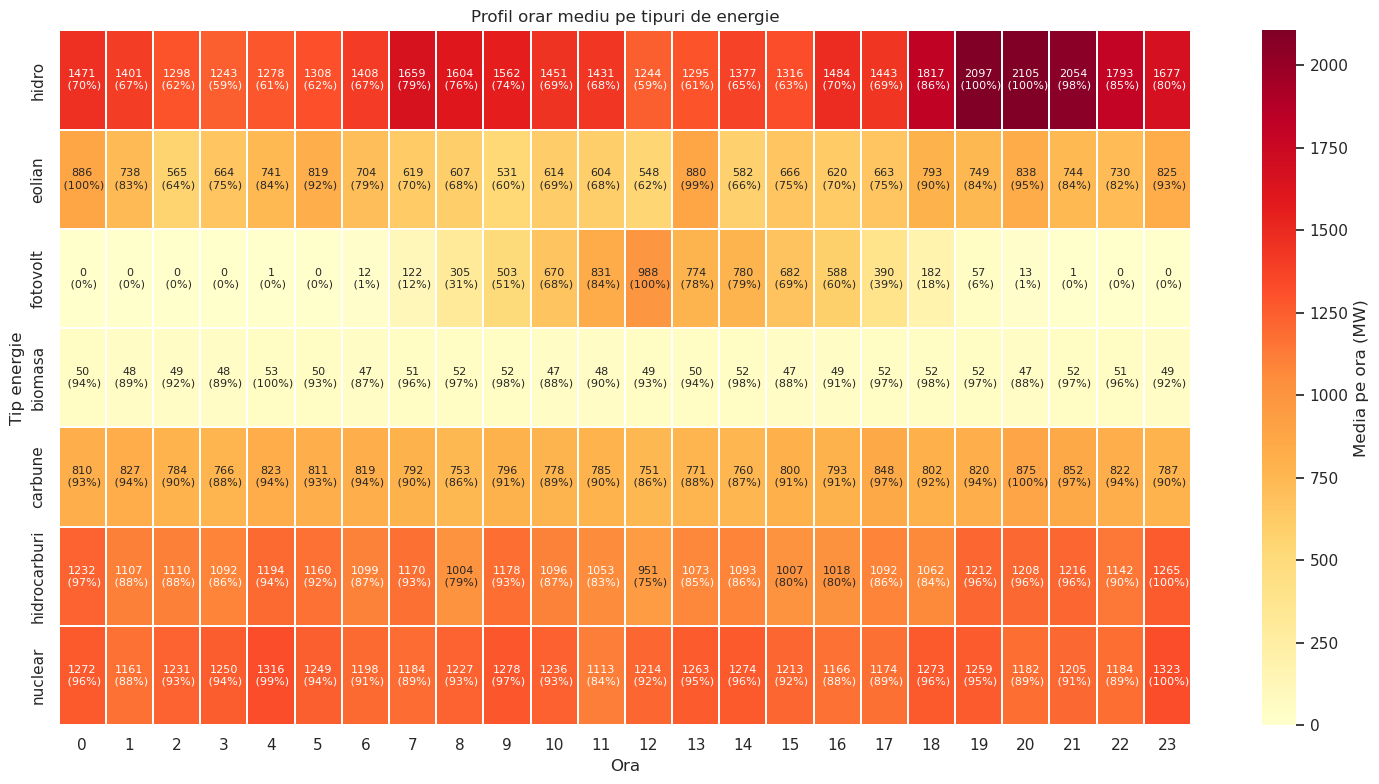

In [62]:
# Analiza corelatiilor (heatmap)
df_clean = data.copy()

# eliminam valorile negative
df_clean[tipuri_energie_cols] = df_clean[tipuri_energie_cols].clip(lower=0)

# agregare dupa ore
hour_order = list(range(24))
cols = tipuri_energie_cols
heat_data = (
    df_clean.groupby("ora")[cols]
    .mean()
    .reindex(hour_order)
    .T
)

labels = heat_data.round(0).astype(int).astype(str) + "\n" \
         " (" + (100*heat_data.div(heat_data.max(axis=1), axis=0)).round(0).astype(int).astype(str) + "%)"

# heatmap cu valori absolute (MW)
plt.figure(figsize=(15, 8))
sns.heatmap(
    heat_data,
    annot=labels,
    fmt="",
    annot_kws={"size": 8},
    cmap="YlOrRd",
    linewidths=0.2,
    #linecolor="white",
    cbar_kws={"label": "Media pe ora (MW)"},
)
plt.title("Profil orar mediu pe tipuri de energie")
plt.xlabel("Ora")
plt.ylabel("Tip energie")
plt.tight_layout()
plt.show()


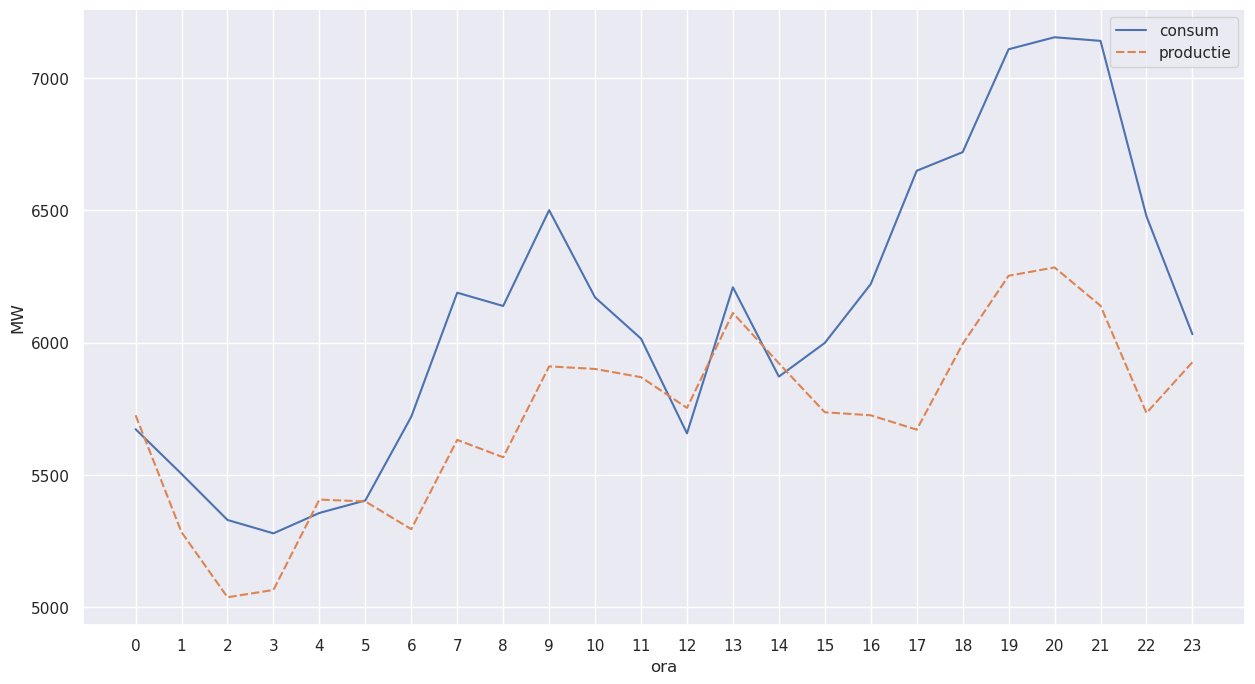

In [63]:
lineplot_data = (
    df_clean.groupby("ora")[["consum", "productie"]]
    .mean()
    .reindex(hour_order)
)


plt.figure(figsize=(15, 8))
plt.xticks(ticks=hour_order)
plt.xlabel("ora")
plt.ylabel("MW")

sns.lineplot(lineplot_data)
plt.show()

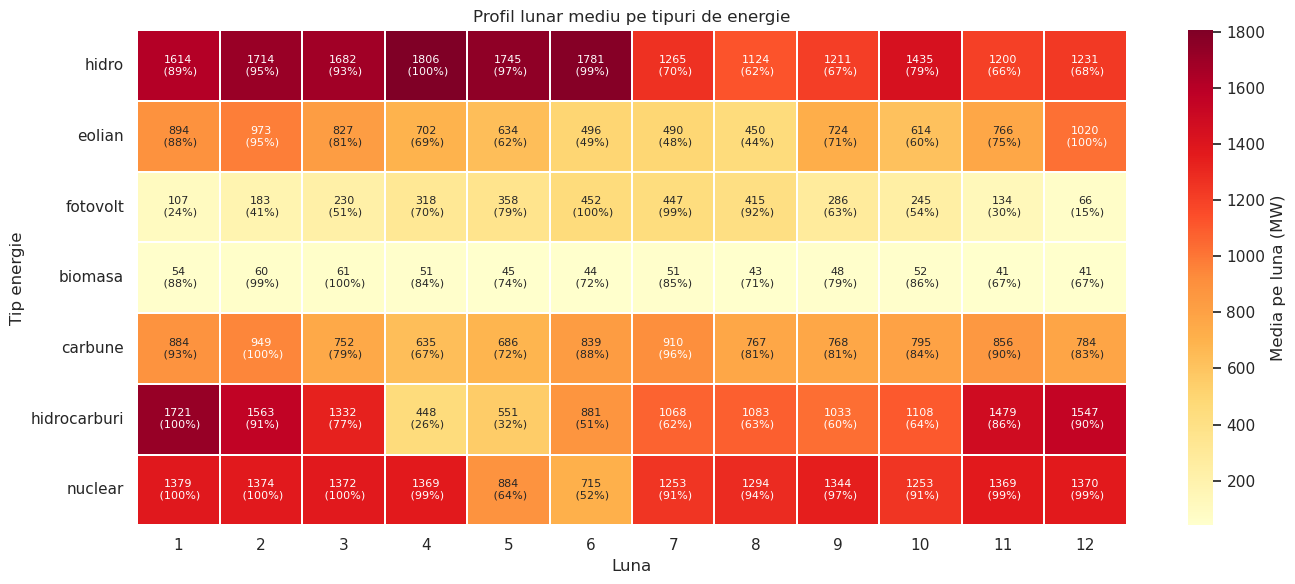

In [64]:
# agregare dupa luni
months_order = sorted(df_clean["luna"].unique().tolist())

heat_data = (
    df_clean.groupby("luna")[tipuri_energie_cols]
    .mean()
    .reindex(months_order)
    .T
)

labels = heat_data.round(0).astype(int).astype(str) + "\n" \
         " (" + (100*heat_data.div(heat_data.max(axis=1), axis=0)).round(0).astype(int).astype(str) + "%)"

# heatmap cu valori absolute (MW)
plt.figure(figsize=(14, 6))
sns.heatmap(
    heat_data,
    annot=labels,
    fmt="",
    annot_kws={"size": 8},
    cmap="YlOrRd",
    linewidths=0.3,
    #linecolor="white",
    cbar_kws={"label": "Media pe luna (MW)"},
)
plt.title("Profil lunar mediu pe tipuri de energie")
plt.xlabel("Luna")
plt.ylabel("Tip energie")
plt.tight_layout()
plt.show()

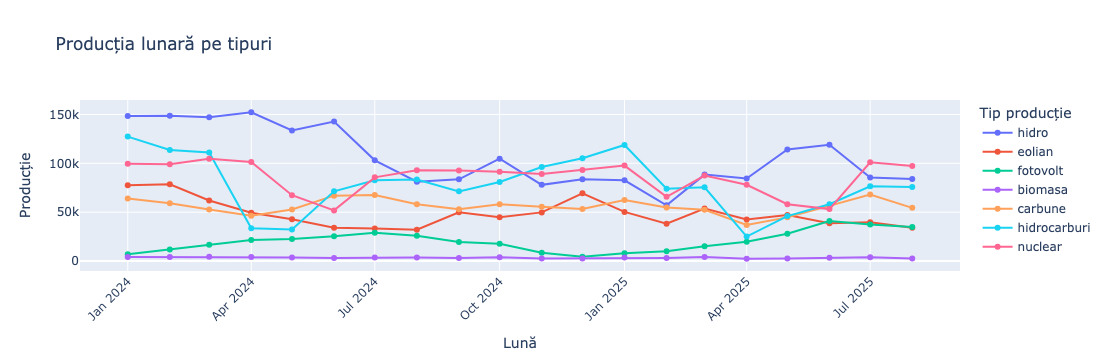

In [212]:
# Aggregarea dupa luni

monthly = (
    data
    .groupby(['an', 'luna'], as_index=False)[tipuri_energie_cols]
    .sum()
    .sort_values(['an', 'luna'])
)

# etichetă de tip "2025-08" pentru axa X
monthly['year_month'] = (monthly['an'].astype(str) + '-' + monthly['luna'].astype(str).str.zfill(2))

montly_melt = monthly.melt(
    id_vars=['an', 'luna', 'year_month'],
    value_vars=tipuri_energie_cols,
    var_name='tip',
    value_name='productie'
)

fig = px.line(
    monthly_melt,
    x='year_month',
    y='productie',
    color='tip',
    markers=True,
    title='Producția lunară pe tipuri',
    labels={'year_month': 'Lună', 'productie': 'Producție', 'tip': 'Tip producție'}
)

fig.update_layout(xaxis_tickangle=-45)
fig.show()

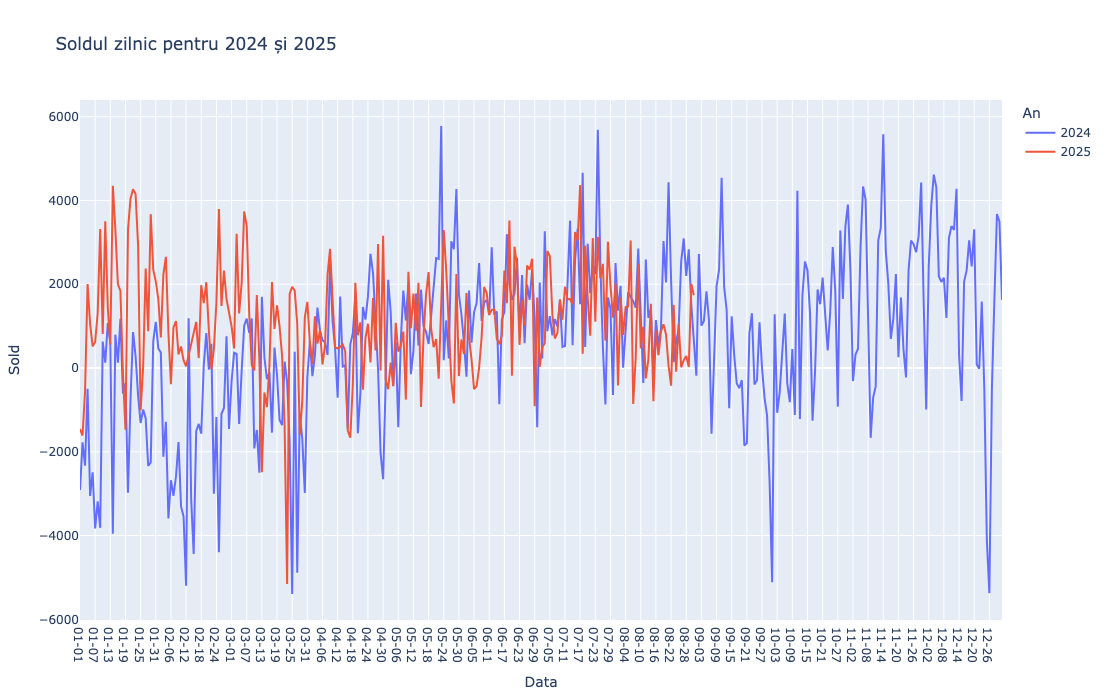

In [176]:
# Soldul zilnic pentru 2024 și 2025
df = data.copy()
df = df[df['an'].isin([2024, 2025])]
daily = (
    df
    .groupby(['an', 'luna', 'zi'], as_index=False)["sold"]
    .sum()
    .sort_values(['an', 'luna', 'zi'])
)
daily["luna_zi"] = (daily["luna"].astype(str).str.zfill(2) + '-' + daily["zi"].astype(str).str.zfill(2))
daily["luna_zi"] = daily["luna_zi"].astype("category")

fig = px.line(
    daily,
    x='luna_zi',
    y='sold',
    color='an',           # linii separate pentru 2024 vs 2025
    markers=False,
    title='Soldul zilnic pentru 2024 și 2025',
    labels={
        'luna_zi': 'Data',
        'sold': 'Sold',
        'an': 'An'
    }
)

fig.update_layout(
    xaxis_title='Data',
    xaxis_type='category',
    yaxis_title='Sold',
    height=700,
)
fig.show()

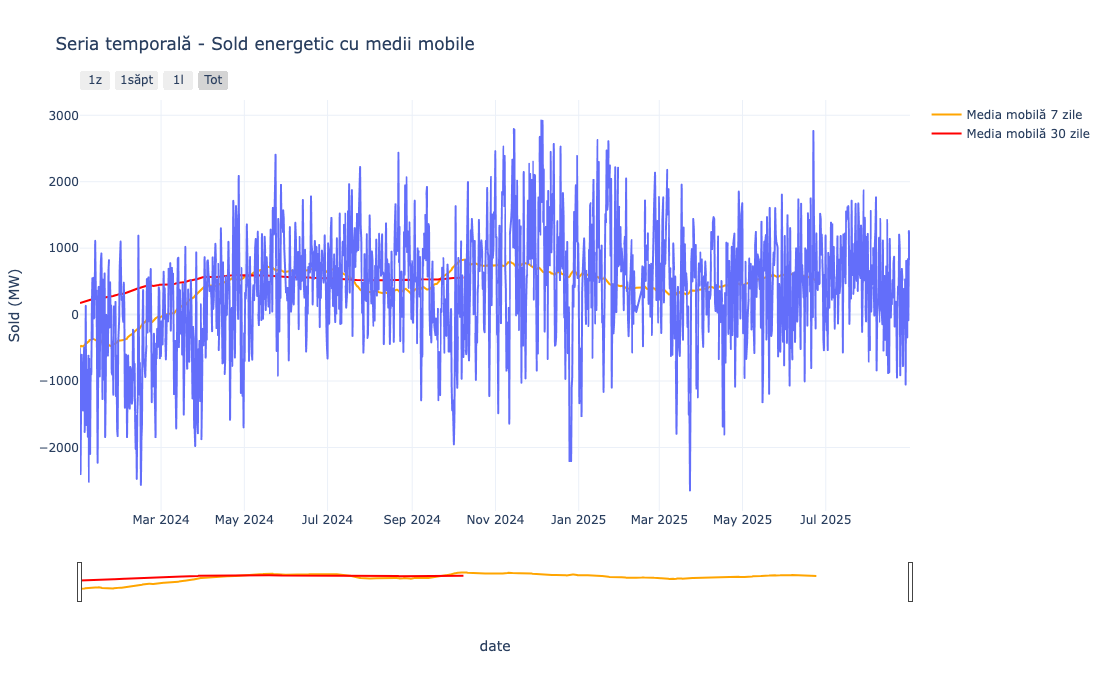

In [177]:
# Seria temporară pe sold
df = data.copy()

# Calcul media mobilă
df['sold_ma7'] = df['sold'].rolling(window=7*24).mean()  # 7 zile
df['sold_ma30'] = df['sold'].rolling(window=30*24).mean()  # 30 zile

fig = px.line(df, x='date', y='sold', 
              title='Seria temporală - Sold energetic cu medii mobile')

fig.add_scatter(x=df['date'], y=df['sold_ma7'], 
                mode='lines', name='Media mobilă 7 zile',
                line=dict(color='orange', width=2))

fig.add_scatter(x=df['date'], y=df['sold_ma30'], 
                mode='lines', name='Media mobilă 30 zile',
                line=dict(color='red', width=2))

fig.update_layout(
    hovermode='x unified',
    height=700,
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1z", step="day", stepmode="backward"),
                dict(count=7, label="1săpt", step="day", stepmode="backward"),
                dict(count=1, label="1l", step="month", stepmode="backward"),
                dict(step="all", label="Tot")
            ])
        ),
        rangeslider=dict(visible=True),
        type="date"
    ),
    yaxis_title='Sold (MW)',
    template='plotly_white'
)

fig.show()

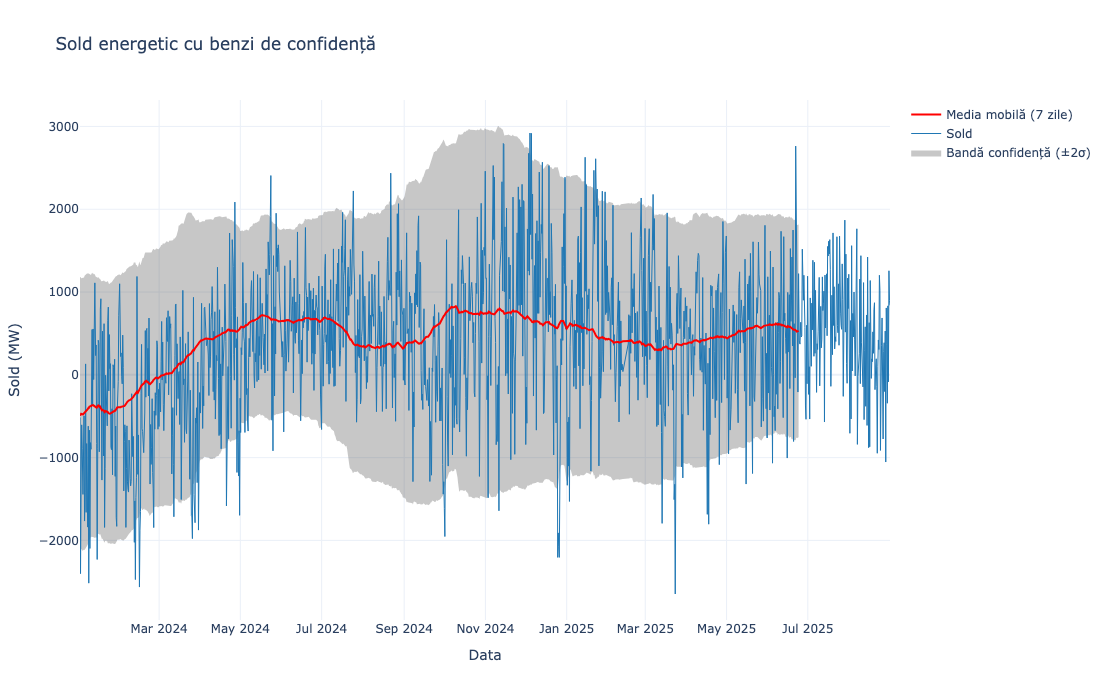

In [181]:
# Calcul statistici pentru benzi

df = df.copy()

window = 24*7  # 7 zile
df['sold_mean'] = df['sold'].rolling(window=window).mean()
df['sold_std'] = df['sold'].rolling(window=window).std()
df['upper_band'] = df['sold_mean'] + 2*df['sold_std']
df['lower_band'] = df['sold_mean'] - 2*df['sold_std']

# Creăm figura
fig = go.Figure()

# Banda de confidență
fig.add_trace(go.Scatter(
    x=df['date'], y=df['upper_band'],
    mode='lines', line=dict(width=0),
    showlegend=False, name='Upper Band'
))

fig.add_trace(go.Scatter(
    x=df['date'], y=df['lower_band'],
    mode='lines', line=dict(width=0),
    fillcolor='rgba(68, 68, 68, 0.3)',
    fill='tonexty',
    showlegend=True, name='Bandă confidență (±2σ)'
))

# Seria principală
fig.add_trace(go.Scatter(
    x=df['date'], y=df['sold'],
    mode='lines', name='Sold',
    line=dict(color='#1f77b4', width=1)
))

# Media mobilă
fig.add_trace(go.Scatter(
    x=df['date'], y=df['sold_mean'],
    mode='lines', name='Media mobilă (7 zile)',
    line=dict(color='red', width=2)
))

fig.update_layout(
    title='Sold energetic cu benzi de confidență',
    xaxis_title='Data',
    yaxis_title='Sold (MW)',
    hovermode='x unified',
    height=700,
    template='plotly_white'
)

fig.show()

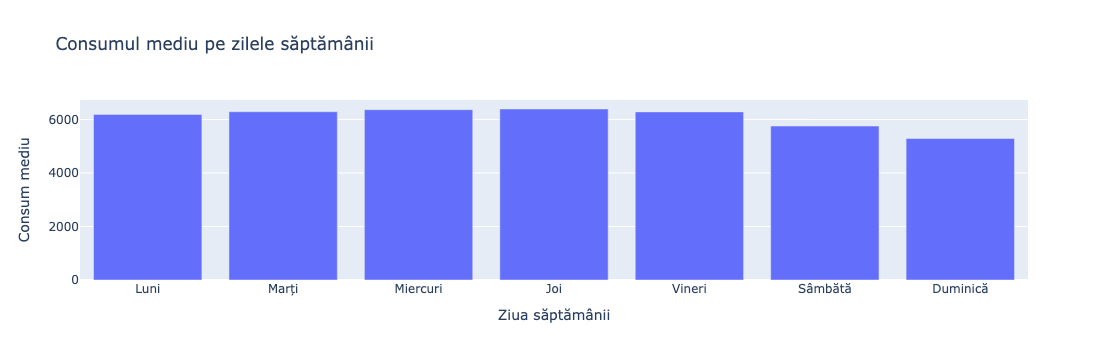

In [183]:
# Consumul mediu pe zilele săptămânii

df = data.copy()

zile_map = {
    0: 'Luni', 1: 'Marți', 2: 'Miercuri',
    3: 'Joi', 4: 'Vineri', 5: 'Sâmbătă', 6: 'Duminică'
}

df['ziSapt_nume'] = df['ziSapt'].map(zile_map)

consum_mediu_zi = (
    df
    .groupby('ziSapt_nume', sort=False)['consum']
    .mean()
    .reindex(['Luni','Marți','Miercuri','Joi','Vineri','Sâmbătă','Duminică'])
)

consum_mediu_df = consum_mediu_zi.reset_index(name='consum_mediu')

fig = px.bar(
    consum_mediu_df,
    x='ziSapt_nume',
    y='consum_mediu',
    category_orders={'ziSapt_nume': ['Luni','Marți','Miercuri','Joi','Vineri','Sâmbătă','Duminică']},
    labels={'ziSapt_nume': 'Ziua săptămânii', 'consum_mediu': 'Consum mediu'},
    title='Consumul mediu pe zilele săptămânii'
)
fig.show()

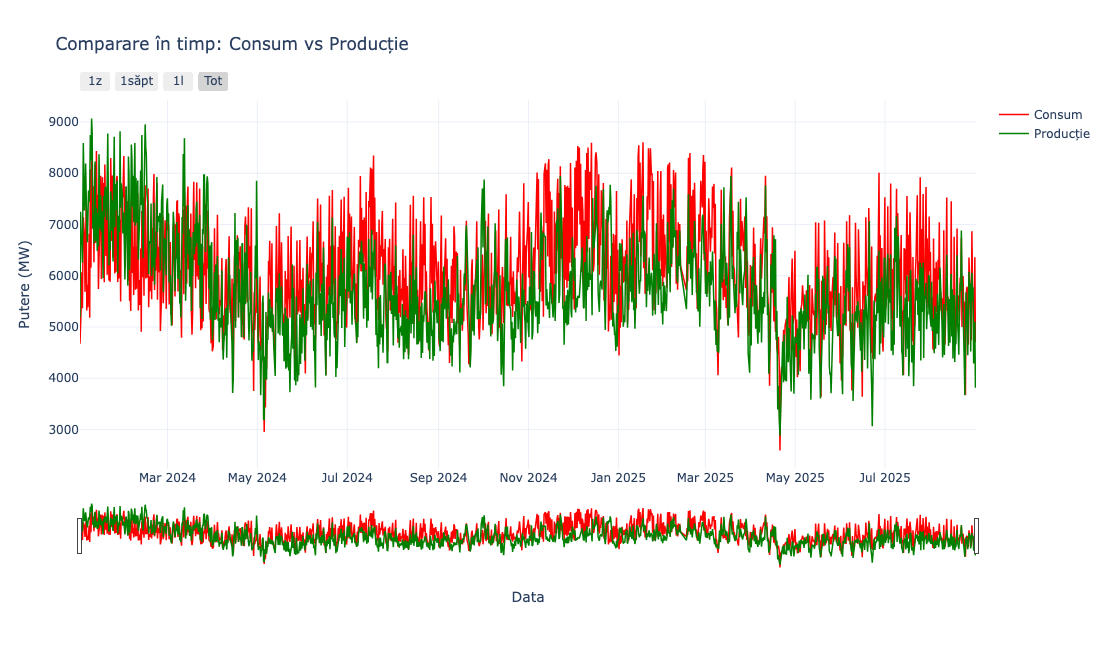

In [185]:
# Comparare grafică între consum și producție
# Linie în timp: consum vs producție

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=data['date'], y=data['consum'],
    mode='lines',
    name='Consum',
    line=dict(color='red', width=1.5)
))

fig.add_trace(go.Scatter(
    x=data['date'], y=data['productie'],
    mode='lines',
    name='Producție',
    line=dict(color='green', width=1.5)
))

fig.update_layout(
    title='Comparare în timp: Consum vs Producție',
    xaxis_title='Data',
    yaxis_title='Putere (MW)',
    hovermode='x unified',
    height=650,
    template='plotly_white'
)

fig.update_layout(
    xaxis=dict(
        rangeselector=dict(
            buttons=list([
                dict(count=1, label="1z", step="day", stepmode="backward"),
                dict(count=7, label="1săpt", step="day", stepmode="backward"),
                dict(count=1, label="1l", step="month", stepmode="backward"),
                dict(step="all", label="Tot")
            ])
        ),
        rangeslider=dict(visible=True),
        type="date"
    )
)

fig.show()

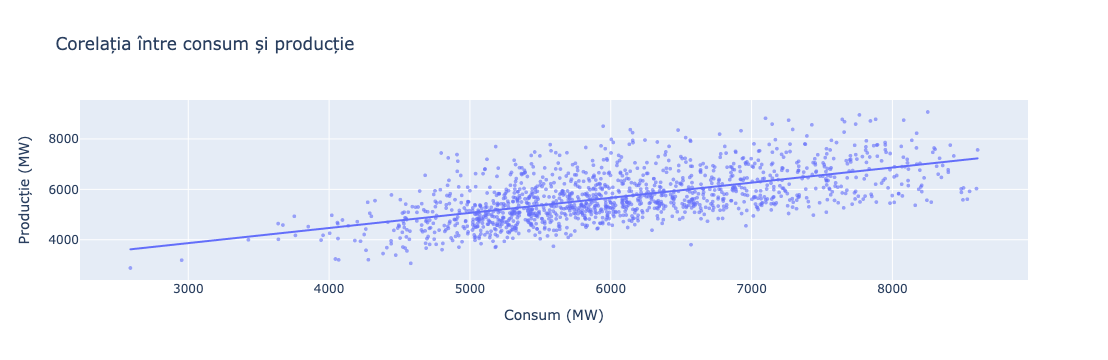

In [186]:
# Comparare grafică între consum și producție
# Scatter consum vs producție
fig = px.scatter(
    data,
    x='consum',
    y='productie',
    labels={'consum': 'Consum (MW)', 'productie': 'Producție (MW)'},
    title='Corelația între consum și producție',
    trendline='ols'
)

fig.update_traces(marker=dict(size=4, opacity=0.6))
fig.show()

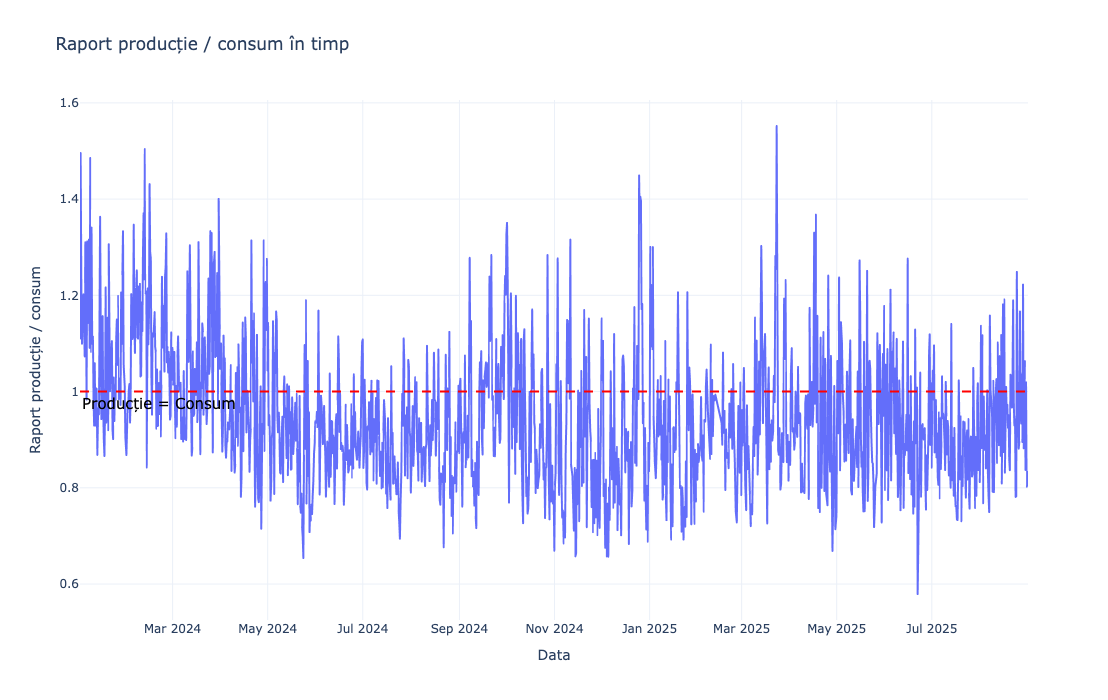

In [198]:
# Comparare grafică între consum și producție
# Raport producție / consum în timp

df = data.copy()

df['raport_prod_consum'] = df['productie'] / df['consum']

fig = px.line(
    df,
    x='date',
    y='raport_prod_consum',
    height=700,
    labels={'date': 'Data', 'raport_prod_consum': 'Raport producție / consum'},
    title='Raport producție / consum în timp',
    template='plotly_white'
)

fig.add_hline(y=1, line_dash='dash', line_color='red', annotation_font_color='black',
              annotation_font_size=15,
              annotation_text='Producție = Consum', annotation_position='bottom left')

fig.show()

In [200]:
df = data.copy()
df.columns

Index(['date', 'carbune', 'consum', 'hidro', 'hidrocarburi', 'nuclear',
       'eolian', 'productie', 'fotovolt', 'biomasa', 'stocare', 'sold', 'an',
       'luna', 'zi', 'ora', 'minute', 'ziSapt', 'ziSapt_nume'],
      dtype='object')

In [202]:
col = ['date', 'carbune']
df[col]

,date,carbune
0,2025-08-31 16:55:27,582
1,2025-08-31 07:25:32,612
2,2025-08-30 21:56:13,606
3,2025-08-30 12:25:36,606
4,2025-08-30 02:25:29,607
...,...,...
1389,2024-01-03 06:29:06,747
1390,2024-01-02 20:59:28,865
1391,2024-01-02 11:29:08,840
1392,2024-01-01 23:59:05,714
